In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv(r"C:\Users\sinha\Downloads\salary-predection-app\salary_data.csv")

df.head()

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [5]:
print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(607, 12)


In [6]:
print(df.columns)

Index(['Unnamed: 0', 'work_year', 'experience_level', 'employment_type',
       'job_title', 'salary', 'salary_currency', 'salary_in_usd',
       'employee_residence', 'remote_ratio', 'company_location',
       'company_size'],
      dtype='str')


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Unnamed: 0          607 non-null    int64
 1   work_year           607 non-null    int64
 2   experience_level    607 non-null    str  
 3   employment_type     607 non-null    str  
 4   job_title           607 non-null    str  
 5   salary              607 non-null    int64
 6   salary_currency     607 non-null    str  
 7   salary_in_usd       607 non-null    int64
 8   employee_residence  607 non-null    str  
 9   remote_ratio        607 non-null    int64
 10  company_location    607 non-null    str  
 11  company_size        607 non-null    str  
dtypes: int64(5), str(7)
memory usage: 73.8 KB


In [8]:
df.isnull().sum()

Unnamed: 0            0
work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df = df.drop_duplicates()

print("Duplicates Removed")

Duplicates Removed


In [11]:
df.describe()

,Unnamed: 0,work_year,salary,salary_in_usd,remote_ratio
count,607.000000,607.000000,6.070000e+02,607.000000,607.00000
mean,303.000000,2021.405272,3.240001e+05,112297.869852,70.92257
std,175.370085,0.692133,1.544357e+06,70957.259411,40.70913
min,0.000000,2020.000000,4.000000e+03,2859.000000,0.00000
25%,151.500000,2021.000000,7.000000e+04,62726.000000,50.00000
50%,303.000000,2022.000000,1.150000e+05,101570.000000,100.00000
75%,454.500000,2022.000000,1.650000e+05,150000.000000,100.00000
max,606.000000,2022.000000,3.040000e+07,600000.000000,100.00000


In [12]:
average_salary = df["salary_in_usd"].mean()

print("Average Salary in USD:")
print(average_salary)

Average Salary in USD:
112297.86985172982


In [13]:
highest_salary = df["salary_in_usd"].max()

print("Highest Salary:")
print(highest_salary)

Highest Salary:
600000


In [14]:
lowest_salary = df["salary_in_usd"].min()

print("Lowest Salary:")
print(lowest_salary)

Lowest Salary:
2859


In [15]:
df["job_title"].value_counts().head(10)

job_title
Data Scientist                143
Data Engineer                 132
Data Analyst                   97
Machine Learning Engineer      41
Research Scientist             16
Data Science Manager           12
Data Architect                 11
Machine Learning Scientist      8
Big Data Engineer               8
Data Science Consultant         7
Name: count, dtype: int64

In [16]:
top_jobs = df.groupby("job_title")["salary_in_usd"].mean()

top_jobs.sort_values(ascending=False).head(10)

job_title
Data Analytics Lead         405000.000000
Principal Data Engineer     328333.333333
Financial Data Analyst      275000.000000
Principal Data Scientist    215242.428571
Director of Data Science    195074.000000
Data Architect              177873.909091
Applied Data Scientist      175655.000000
Analytics Engineer          175000.000000
Data Specialist             165000.000000
Head of Data                160162.600000
Name: salary_in_usd, dtype: float64

In [17]:
df["experience_level"].value_counts()

experience_level
SE    280
MI    213
EN     88
EX     26
Name: count, dtype: int64

In [18]:
df["company_size"].value_counts()

company_size
M    326
L    198
S     83
Name: count, dtype: int64

In [19]:
df["remote_ratio"].value_counts()

remote_ratio
100    381
0      127
50      99
Name: count, dtype: int64

In [20]:
df = df[
    [
        "experience_level",
        "employment_type",
        "job_title",
        "salary_in_usd",
        "employee_residence",
        "remote_ratio",
        "company_location",
        "company_size"
    ]
]

df.head()

,experience_level,employment_type,job_title,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,MI,FT,Data Scientist,79833,DE,0,DE,L
1,SE,FT,Machine Learning Scientist,260000,JP,0,JP,S
2,SE,FT,Big Data Engineer,109024,GB,50,GB,M
3,MI,FT,Product Data Analyst,20000,HN,0,HN,S
4,SE,FT,Machine Learning Engineer,150000,US,50,US,L


In [21]:
df = df.rename(columns={
    "salary_in_usd": "salary"
})

df.head()

,experience_level,employment_type,job_title,salary,employee_residence,remote_ratio,company_location,company_size
0,MI,FT,Data Scientist,79833,DE,0,DE,L
1,SE,FT,Machine Learning Scientist,260000,JP,0,JP,S
2,SE,FT,Big Data Engineer,109024,GB,50,GB,M
3,MI,FT,Product Data Analyst,20000,HN,0,HN,S
4,SE,FT,Machine Learning Engineer,150000,US,50,US,L


In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   experience_level    607 non-null    str  
 1   employment_type     607 non-null    str  
 2   job_title           607 non-null    str  
 3   salary              607 non-null    int64
 4   employee_residence  607 non-null    str  
 5   remote_ratio        607 non-null    int64
 6   company_location    607 non-null    str  
 7   company_size        607 non-null    str  
dtypes: int64(2), str(6)
memory usage: 53.0 KB


In [23]:
from sklearn.preprocessing import LabelEncoder

In [24]:
encoder = LabelEncoder()

In [25]:
df["experience_level"] = encoder.fit_transform(df["experience_level"])

df["employment_type"] = encoder.fit_transform(df["employment_type"])

df["job_title"] = encoder.fit_transform(df["job_title"])

df["employee_residence"] = encoder.fit_transform(df["employee_residence"])

df["company_location"] = encoder.fit_transform(df["company_location"])

df["company_size"] = encoder.fit_transform(df["company_size"])

In [26]:
df.head()

,experience_level,employment_type,job_title,salary,employee_residence,remote_ratio,company_location,company_size
0,2,2,22,79833,14,0,12,0
1,3,2,41,260000,32,0,29,2
2,3,2,7,109024,20,50,18,1
3,2,2,47,20000,23,0,20,2
4,3,2,38,150000,55,50,48,0


In [27]:
X = df.drop("salary", axis=1)

y = df["salary"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (607, 7)
Target Shape: (607,)


In [28]:
X.head()

,experience_level,employment_type,job_title,employee_residence,remote_ratio,company_location,company_size
0,2,2,22,14,0,12,0
1,3,2,41,32,0,29,2
2,3,2,7,20,50,18,1
3,2,2,47,23,0,20,2
4,3,2,38,55,50,48,0


In [29]:
y.head()

0     79833
1    260000
2    109024
3     20000
4    150000
Name: salary, dtype: int64

In [30]:
df.to_csv("../cleaned_salary_data.csv", index=False)

print("Cleaned Dataset Saved Successfully")

Cleaned Dataset Saved Successfully


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [32]:
import pandas as pd

df = pd.read_csv(r"C:\Users\sinha\Downloads\salary-predection-app\cleaned_salary_data.csv")

df.head()

,experience_level,employment_type,job_title,salary,employee_residence,remote_ratio,company_location,company_size
0,2,2,22,79833,14,0,12,0
1,3,2,41,260000,32,0,29,2
2,3,2,7,109024,20,50,18,1
3,2,2,47,20000,23,0,20,2
4,3,2,38,150000,55,50,48,0


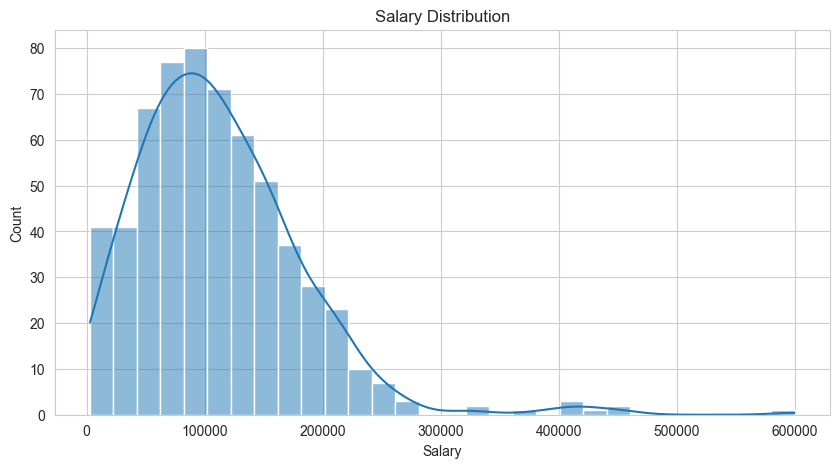

In [33]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["salary"],
    bins=30,
    kde=True
)

plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Count")

plt.show()

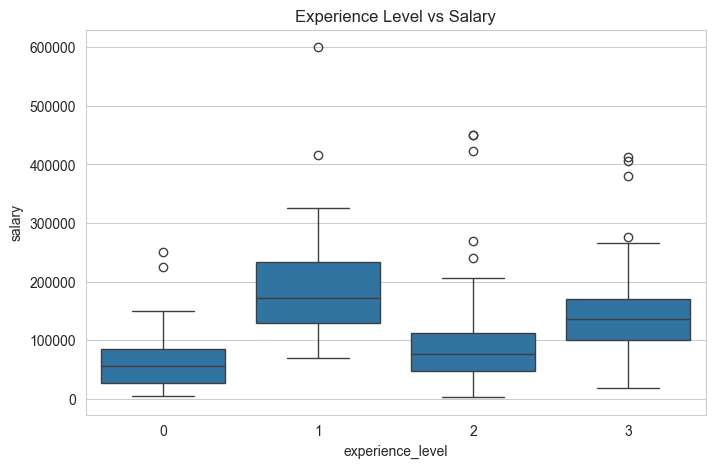

In [34]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x=df["experience_level"],
    y=df["salary"]
)

plt.title("Experience Level vs Salary")

plt.show()

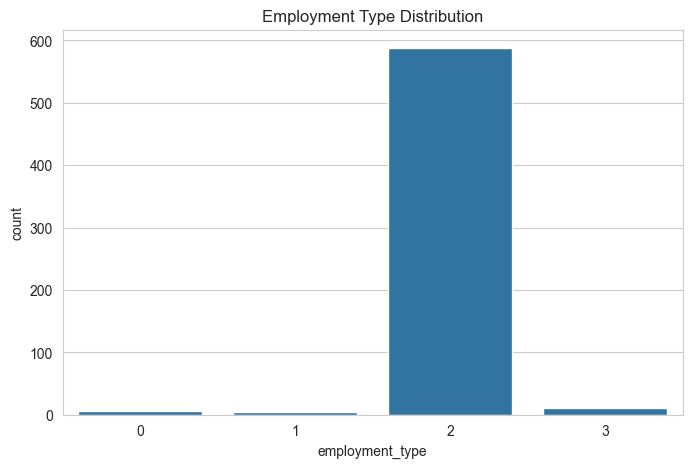

In [35]:
plt.figure(figsize=(8, 5))

sns.countplot(
    x=df["employment_type"]
)

plt.title("Employment Type Distribution")

plt.show()

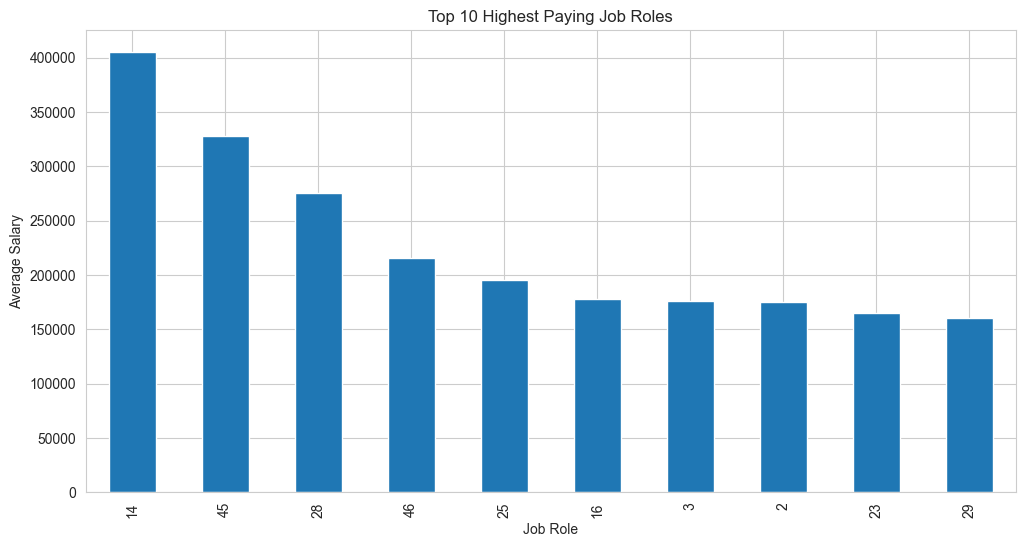

In [36]:
top_jobs = df.groupby("job_title")["salary"].mean()

top_jobs = top_jobs.sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(12, 6))

top_jobs.plot(kind="bar")

plt.title("Top 10 Highest Paying Job Roles")
plt.xlabel("Job Role")
plt.ylabel("Average Salary")

plt.show()

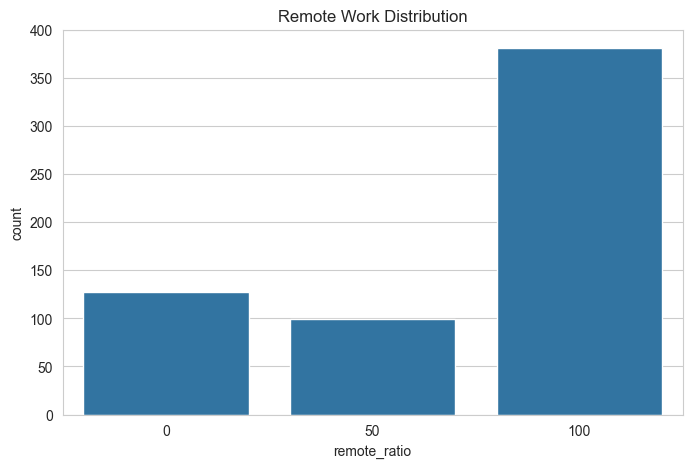

In [37]:
plt.figure(figsize=(8, 5))

sns.countplot(
    x=df["remote_ratio"]
)

plt.title("Remote Work Distribution")

plt.show()

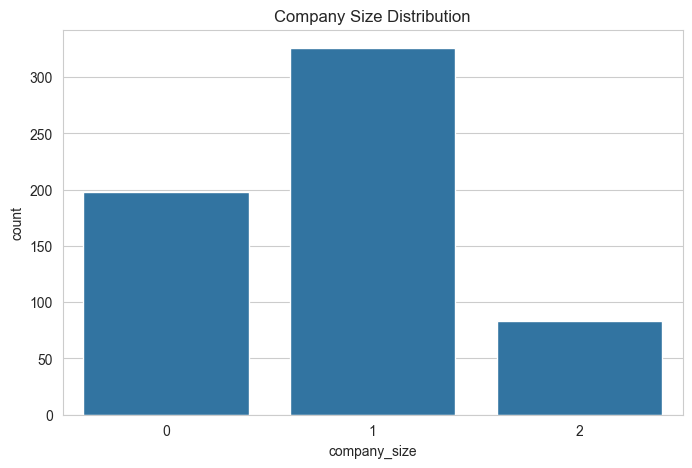

In [38]:
plt.figure(figsize=(8, 5))

sns.countplot(
    x=df["company_size"]
)

plt.title("Company Size Distribution")

plt.show()

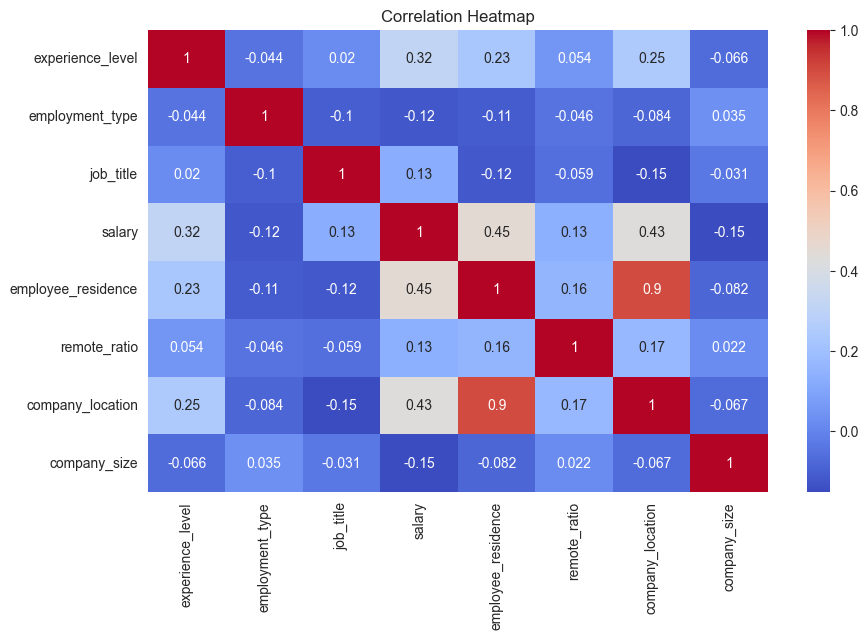

In [39]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

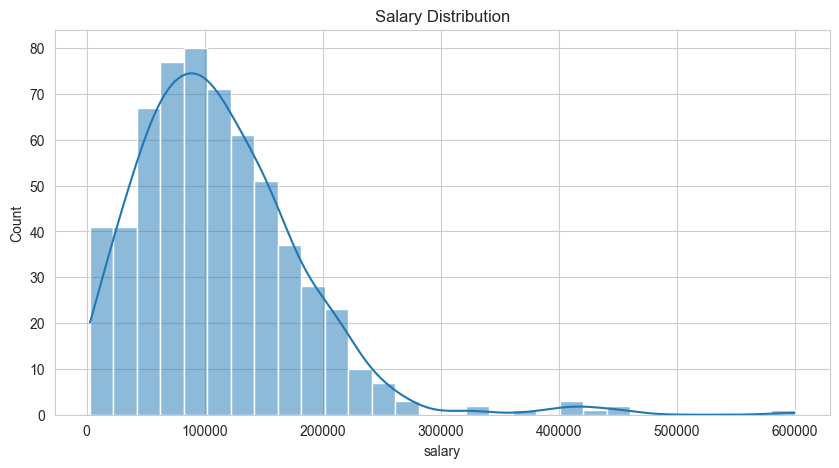

In [40]:
plt.figure(figsize=(10, 5))

sns.histplot(df["salary"], bins=30, kde=True)

plt.title("Salary Distribution")

plt.savefig("../images/salary_distribution.png")

plt.show()

In [41]:
plt.style.use("ggplot")

In [42]:
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

In [43]:
df = pd.read_csv("../cleaned_salary_data.csv")

df.head()

,experience_level,employment_type,job_title,salary,employee_residence,remote_ratio,company_location,company_size
0,2,2,22,79833,14,0,12,0
1,3,2,41,260000,32,0,29,2
2,3,2,7,109024,20,50,18,1
3,2,2,47,20000,23,0,20,2
4,3,2,38,150000,55,50,48,0


In [44]:
X = df.drop("salary", axis=1)

y = df["salary"]

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (485, 7)
Testing Data: (122, 7)


In [46]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

print("Linear Regression Model Trained")

Linear Regression Model Trained


In [47]:
lr_predictions = lr_model.predict(X_test)

lr_predictions[:5]

array([145155.02956891, 145155.02956891, 117793.67969279, 195113.41469879,
       123585.23849375])

In [48]:
lr_r2 = r2_score(y_test, lr_predictions)

lr_mae = mean_absolute_error(y_test, lr_predictions)

print("Linear Regression R2 Score:", lr_r2)

print("Linear Regression MAE:", lr_mae)

Linear Regression R2 Score: 0.33232045093348905
Linear Regression MAE: 35366.61110416696


In [49]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest Model Trained")

Random Forest Model Trained


In [50]:
rf_predictions = rf_model.predict(X_test)

rf_predictions[:5]

array([140939.94090518, 140939.94090518, 134828.60714286, 181944.78      ,
        43703.49      ])

In [51]:
rf_r2 = r2_score(y_test, rf_predictions)

rf_mae = mean_absolute_error(y_test, rf_predictions)

print("Random Forest R2 Score:", rf_r2)

print("Random Forest MAE:", rf_mae)

Random Forest R2 Score: 0.5558353662919294
Random Forest MAE: 27794.48501202959


In [52]:
print("Linear Regression R2 Score:", lr_r2)

print("Random Forest R2 Score:", rf_r2)

Linear Regression R2 Score: 0.33232045093348905
Random Forest R2 Score: 0.5558353662919294


In [53]:
joblib.dump(
    rf_model,
    "../model/salary_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


In [54]:
importance = rf_model.feature_importances_

feature_names = X.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df

,Feature,Importance
3,employee_residence,0.377830
2,job_title,0.336155
0,experience_level,0.155181
6,company_size,0.055589
4,remote_ratio,0.039040
5,company_location,0.028872
1,employment_type,0.007332


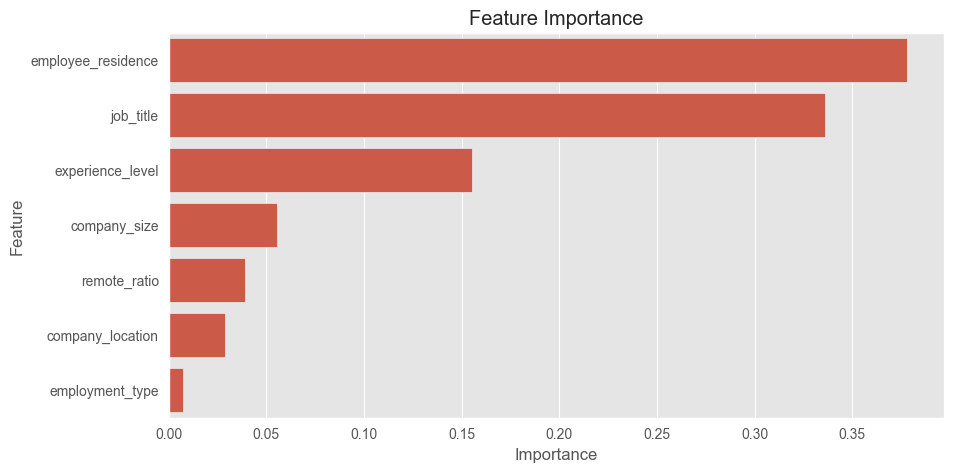

In [55]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance_df
)

plt.title("Feature Importance")

plt.show()